In [22]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import Likelihood, Fstatistics
from Triangle_BBH.Fisher import *

# import multiprocessing
# if __name__=='__main__':
#     multiprocessing.set_start_method("fork")
    
import bilby 

# np.random.seed(114515)

In [23]:
t_start = 0. * DAY # start time in s
Tobs = 5. * DAY # data length in s 
t_end = t_start + Tobs # end time in s 
dt = 10. # time cadance in s 
fsample = 1. / dt # sampling rate in Hz 
data_frequencies_full = np.fft.rfftfreq(n=int(Tobs/dt), d=dt) # frequecies where waveform will be calculated 
delta_f = 1. / Tobs

# mask the "null" frequencies, which may cause singularity in the calculation of likelihood 
mask = np.ones_like(data_frequencies_full, dtype=bool)
for i in range(1, 50): 
    mask_idx = np.where(np.abs(data_frequencies_full - i*0.025)<i*3e-4)[0]
    mask[mask_idx] = False 

# remove the frequencies below Taiji sensitive band 
mask_idx = np.where(data_frequencies_full < 1e-5)[0]
mask[mask_idx] = False 

data_frequencies = data_frequencies_full[mask]

data_frequencies.shape, data_frequencies_full.shape 

((21077,), (21601,))

In [24]:
PSDfunc = TDIPSDs()
data_psd = PSDfunc.PSD_A2(data_frequencies)

In [25]:
# the path of Taiji orbit 
orbit = Orbit(
    OrbitDir="../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB", 
    ) 

# initialize  waveform generator 
WFG1 = WaveformGenerator(
    mode="primary", 
    # mode="full", 
)
WFG2 = WaveformGeneratorFRef(
    mode="primary", 
    # mode="full", 
)

# initialize response generator 
FDTDI1 = FDTDIResponseGenerator(
    orbit_class=orbit, 
    waveform_generator=WFG1, 
)
FDTDI2 = FDTDIResponseGeneratorFRef(
    orbit_class=orbit, 
    waveform_generator=WFG2, 
)

# response settings 
response_kwargs_interp1 = dict(
    fmin=1e-5, # used to calculate freq grid
    fmax=1e-1, # used to calculate freq grid
    Nfreqs=1024, # used to calculate freq grid
    modes=[(2, 2)], 
    tmin=t_start / DAY, # start time in day 
    tmax=t_end / DAY, # end time in day  
    tc_at_constellation=True, # whether tc is the coalescence time at constellation center (True) or SSB (False)
    # tc_at_constellation=False, 
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    output_by_mode=False, 
    interpolation_method='cubic',
)

# response settings 
response_kwargs_interp2 = response_kwargs_interp1.copy()
response_kwargs_interp2.pop("tc_at_constellation")
response_kwargs_interp2["tref_at_constellation"] = response_kwargs_interp1["tc_at_constellation"]


In [26]:
response_kwargs_interp1, response_kwargs_interp2

({'fmin': 1e-05,
  'fmax': 0.1,
  'Nfreqs': 1024,
  'modes': [(2, 2)],
  'tmin': 0.0,
  'tmax': 5.0,
  'tc_at_constellation': True,
  'TDIGeneration': '2nd',
  'optimal_combination': True,
  'output_by_mode': False,
  'interpolation_method': 'cubic'},
 {'fmin': 1e-05,
  'fmax': 0.1,
  'Nfreqs': 1024,
  'modes': [(2, 2)],
  'tmin': 0.0,
  'tmax': 5.0,
  'TDIGeneration': '2nd',
  'optimal_combination': True,
  'output_by_mode': False,
  'interpolation_method': 'cubic',
  'tref_at_constellation': True})

In [27]:
lgMc_prior = [5.5, 6.5]
q_prior = [0.1, 1]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tc_prior = [(t_start + 0.3 * Tobs) / DAY , (t_end - 0.3 * Tobs) / DAY] # ensure the inclusion of long enough GW waveform 
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

lgdl_prior = [4., 5.]

# generate source parameter and clean signal 
mbhb_parameters1 = {
    'chirp_mass': np.power(10., np.random.uniform(lgMc_prior[0], lgMc_prior[1])), 
    'mass_ratio': np.random.uniform(q_prior[0], q_prior[1]), 
    'spin_1z': np.random.uniform(s1_prior[0], s1_prior[1]),
    'spin_2z': np.random.uniform(s2_prior[0], s2_prior[1]),
    'coalescence_time': np.random.uniform(tc_prior[0], tc_prior[1]), 
    'coalescence_phase': np.random.uniform(0, TWOPI),
    'luminosity_distance': np.power(10., np.random.uniform(lgdl_prior[0], lgdl_prior[1])), 
    'inclination': np.arccos(np.random.uniform(-1., 1.)), # [rad]
    'longitude': np.random.uniform(lam_prior[0], lam_prior[1]), # [rad]
    'latitude': np.arcsin(np.random.uniform(sinbeta_prior[0], sinbeta_prior[1])), # [rad]
    'psi': np.random.uniform(0, PI) # [rad]
    }

mbhb_parameters2 = mbhb_parameters1.copy() 
mbhb_parameters2.pop("coalescence_time")
mbhb_parameters2.pop("coalescence_phase")
mbhb_parameters2["reference_time"] = mbhb_parameters1["coalescence_time"]
mbhb_parameters2["reference_phase"] = mbhb_parameters1["coalescence_phase"]

mbhb_parameters1, mbhb_parameters2

({'chirp_mass': 1697938.0052528773,
  'mass_ratio': 0.48133043796344177,
  'spin_1z': -0.796166153092141,
  'spin_2z': -0.05395379643517895,
  'coalescence_time': 1.5298316086372543,
  'coalescence_phase': 4.411931753221801,
  'luminosity_distance': 15510.208907263095,
  'inclination': 2.03797068279974,
  'longitude': 5.972962189662077,
  'latitude': -0.9410536727023964,
  'psi': 1.5648902650045797},
 {'chirp_mass': 1697938.0052528773,
  'mass_ratio': 0.48133043796344177,
  'spin_1z': -0.796166153092141,
  'spin_2z': -0.05395379643517895,
  'luminosity_distance': 15510.208907263095,
  'inclination': 2.03797068279974,
  'longitude': 5.972962189662077,
  'latitude': -0.9410536727023964,
  'psi': 1.5648902650045797,
  'reference_time': 1.5298316086372543,
  'reference_phase': 4.411931753221801})

In [28]:
wf_channels1 = FDTDI1.Response(
    mbhb_parameters1, 
    data_frequencies, 
    **response_kwargs_interp1, 
)

response_kwargs_interp2["fref"] = WFG1.f_ref[0]
wf_channels2 = FDTDI2.Response(
    mbhb_parameters2, 
    data_frequencies, 
    **response_kwargs_interp2, 
)

WFG1.f_ref[0], WFG2.fcutarr

(0.0031233715918008768, array([0.00312337]))

In [29]:
print("SNR (interpolated)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels1[:2])**2 / data_psd)))
print("SNR (direct)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels2[:2])**2 / data_psd)))
print("SNR (residual)", np.sqrt(4. / Tobs * np.sum(np.abs(wf_channels1[:2] - wf_channels2[:2])**2 / data_psd)))

SNR (interpolated) 2199.432235638089
SNR (direct) 2199.4293545649725
SNR (residual) 3.6210358176662174


(5e-05, 0.1)

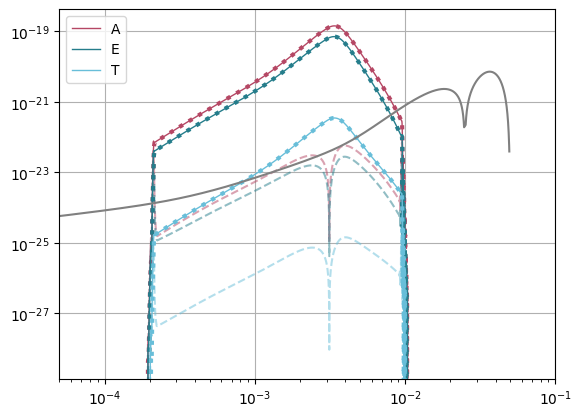

In [30]:
ch_names = ["A", "E", "T"]
ch_colors = [RED, GREEN1, BLUE]
psdfunc = TDIPSDs()
for i in range(3):
    plt.loglog(data_frequencies, np.abs(wf_channels1[i]) * 2. * data_frequencies, color=ch_colors[i], label=ch_names[i], linestyle="-", linewidth=1)
    plt.loglog(data_frequencies, np.abs(wf_channels2[i]) * 2. * data_frequencies, color=ch_colors[i], linestyle=":", linewidth=3)
    plt.loglog(data_frequencies, np.abs(wf_channels1[i] - wf_channels2[i]) * 2. * data_frequencies, color=ch_colors[i], linestyle="--", alpha=0.5)
plt.loglog(data_frequencies, np.sqrt(psdfunc.PSD_X2(data_frequencies) * data_frequencies), color="grey")
plt.legend()
plt.grid()
# plt.ylim(1e-25,)
plt.xlim(5e-5, 0.1)

In [31]:
mbhb_parameters1_reflected = get_reflected_parameter_dict(mbhb_parameters1, orbit)
mbhb_parameters2_reflected = get_reflected_parameter_dict_Fref(mbhb_parameters2, orbit)

wf_channels1_reflected = FDTDI1.Response(
    mbhb_parameters1_reflected, 
    data_frequencies, 
    **response_kwargs_interp1, 
)
wf_channels2_reflected = FDTDI2.Response(
    mbhb_parameters2_reflected, 
    data_frequencies, 
    **response_kwargs_interp2, 
)

mbhb_parameters1_reflected, mbhb_parameters2_reflected

({'chirp_mass': 1697938.0052528773,
  'mass_ratio': 0.48133043796344177,
  'spin_1z': -0.796166153092141,
  'spin_2z': -0.05395379643517895,
  'coalescence_time': 1.5298316086372543,
  'coalescence_phase': 4.411931753221801,
  'luminosity_distance': 15510.208907263095,
  'inclination': 1.1036219707900532,
  'longitude': 5.295393396689143,
  'latitude': -0.5094351499850012,
  'psi': 2.9409033374935545},
 {'chirp_mass': 1697938.0052528773,
  'mass_ratio': 0.48133043796344177,
  'spin_1z': -0.796166153092141,
  'spin_2z': -0.05395379643517895,
  'luminosity_distance': 15510.208907263095,
  'inclination': 1.1036219707900532,
  'longitude': 5.295393396689143,
  'latitude': -0.5094351499850012,
  'psi': 2.9409033374935545,
  'reference_time': 1.5298316086372543,
  'reference_phase': 4.411931753221801})

In [32]:
k_fiducial = FDTDI1.WaveVector(parameters=mbhb_parameters1)
k_reflected = FDTDI1.WaveVector(parameters=mbhb_parameters1_reflected)

n12_tc = orbit.ArmVectorfunctions()["12"](mbhb_parameters1["coalescence_time"]*DAY)
n13_tc = orbit.ArmVectorfunctions()["13"](mbhb_parameters1["coalescence_time"]*DAY)
norm_tc = np.cross(n12_tc, n13_tc)
norm_tc_len = np.linalg.norm(norm_tc)
norm_tc = norm_tc / norm_tc_len
R1_tc = orbit.Positionfunctions()["1"](mbhb_parameters1["coalescence_time"]*DAY)
R2_tc = orbit.Positionfunctions()["2"](mbhb_parameters1["coalescence_time"]*DAY)
R3_tc = orbit.Positionfunctions()["3"](mbhb_parameters1["coalescence_time"]*DAY)
R0_tc = (R1_tc + R2_tc + R3_tc) / 3. / C 

print(np.dot(k_fiducial, norm_tc), np.dot(k_reflected, norm_tc), np.dot(k_fiducial, R0_tc), np.dot(k_reflected, R0_tc))

exp_factor_fiducial = np.exp(1.j * TWOPI * response_kwargs_interp2["fref"] * np.dot(k_fiducial, R0_tc))
exp_factor_reflected = np.exp(1.j * TWOPI * response_kwargs_interp2["fref"] * np.dot(k_reflected, R0_tc))
exp_factor_fiducial, exp_factor_reflected

0.3204145879699253 -0.32034611635258525 46.47859732325912 324.4206851951357


((0.6120630521114174+0.7908089657054075j),
 (0.9965175169341345+0.0833836821172283j))

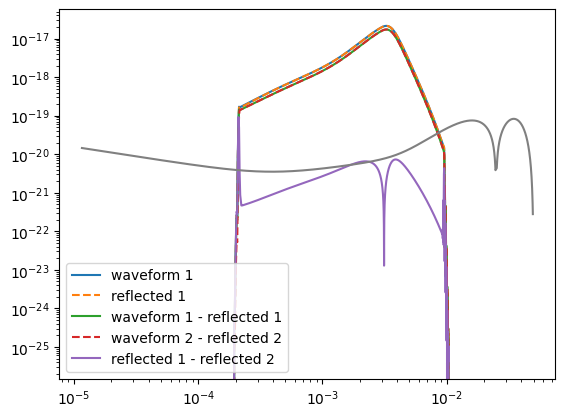

In [33]:
plt.loglog(data_frequencies, np.abs(wf_channels1[0]), label="waveform 1")
plt.loglog(data_frequencies, np.abs(wf_channels1_reflected[0]), linestyle="--", label="reflected 1")
plt.loglog(data_frequencies, np.abs(wf_channels1[0] - wf_channels1_reflected[0]), label="waveform 1 - reflected 1")
plt.loglog(data_frequencies, np.abs(wf_channels2[0] - wf_channels2_reflected[0]), label="waveform 2 - reflected 2", linestyle="--")
plt.loglog(data_frequencies, np.abs(wf_channels1_reflected[0] - wf_channels2_reflected[0]), label="reflected 1 - reflected 2")
plt.loglog(data_frequencies, np.sqrt(psdfunc.PSD_A2(data_frequencies) * data_frequencies) / 2. / data_frequencies, color="grey")
plt.legend()

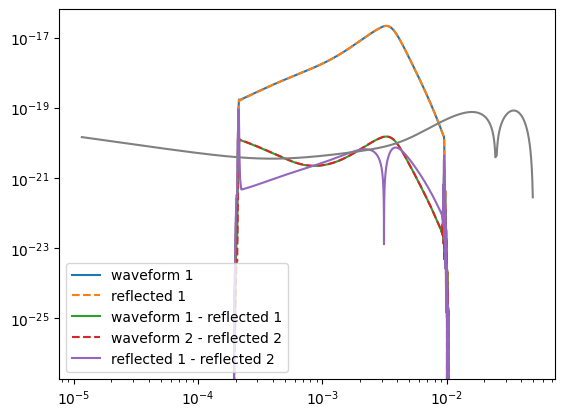

In [35]:
plt.loglog(data_frequencies, np.abs(wf_channels1[0]), label="waveform 1")
plt.loglog(data_frequencies, np.abs(wf_channels1_reflected[0]), linestyle="--", label="reflected 1")
plt.loglog(data_frequencies, np.abs(wf_channels1[0] * exp_factor_fiducial - wf_channels1_reflected[0] * exp_factor_reflected), label="waveform 1 - reflected 1")
plt.loglog(data_frequencies, np.abs(wf_channels2[0] * exp_factor_fiducial - wf_channels2_reflected[0] * exp_factor_reflected), label="waveform 2 - reflected 2", linestyle="--")
plt.loglog(data_frequencies, np.abs(wf_channels1_reflected[0] - wf_channels2_reflected[0]), label="reflected 1 - reflected 2")
plt.loglog(data_frequencies, np.sqrt(psdfunc.PSD_A2(data_frequencies) * data_frequencies) / 2. / data_frequencies, color="grey")
plt.legend()

/var/folders/_f/d29qj88911xdzjc9ffs55hph0000gn/T/ipykernel_52740/2234938529.py:3: RuntimeWarning: invalid value encountered in divide
  delta_phi = np.arctan2(np.imag(wf_channels1[0] / wf_channels1_reflected[0]), np.real(wf_channels1[0] / wf_channels1_reflected[0]))


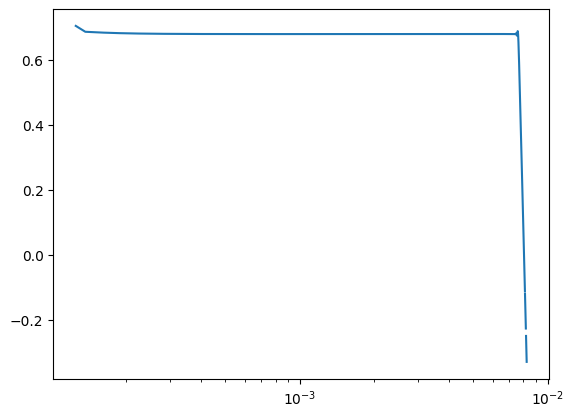

In [13]:
# plt.semilogx(data_frequencies, np.real(wf_channels1[0] / wf_channels1_reflected[0]))
# plt.semilogx(data_frequencies, np.imag(wf_channels1[0] / wf_channels1_reflected[0]))
delta_phi = np.arctan2(np.imag(wf_channels1[0] / wf_channels1_reflected[0]), np.real(wf_channels1[0] / wf_channels1_reflected[0]))
plt.semilogx(data_frequencies, delta_phi / PI)

In [61]:
f1, amp1, pha1, tf1 = WFG1(
    parameters=mbhb_parameters1, 
    Nfreqs=1024, 
    fmin=1e-5, 
    fmax=0.1, 
)

f2, amp2, pha2, tf2 = WFG2(
    parameters=mbhb_parameters2, 
    Nfreqs=1024, 
    fmin=1e-5, 
    fmax=0.1, 
    fref=WFG1.f_ref[0]
)

WFG1.f_ref[0]

0.021837274633169625

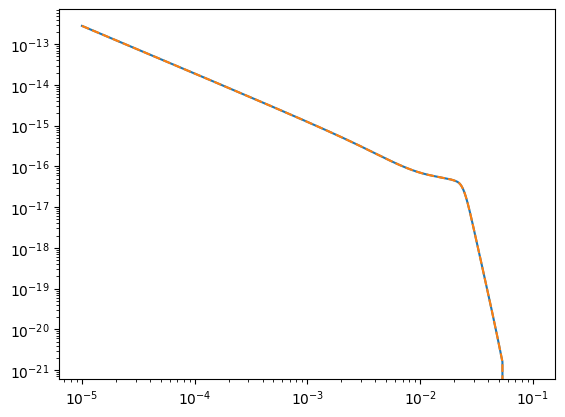

In [62]:
plt.loglog(f1[0], amp1[(2,2)][0])
plt.loglog(f2[0], amp2[(2,2)][0], linestyle="--")

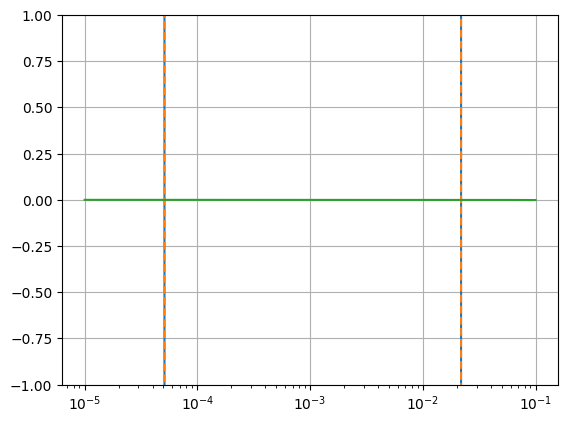

In [63]:
plt.semilogx(f1[0], pha1[(2,2)][0])
plt.semilogx(f2[0], pha2[(2,2)][0], linestyle="--")
plt.semilogx(f1[0], pha1[(2,2)][0]-pha2[(2,2)][0])
plt.ylim(-1, 1)
plt.grid()

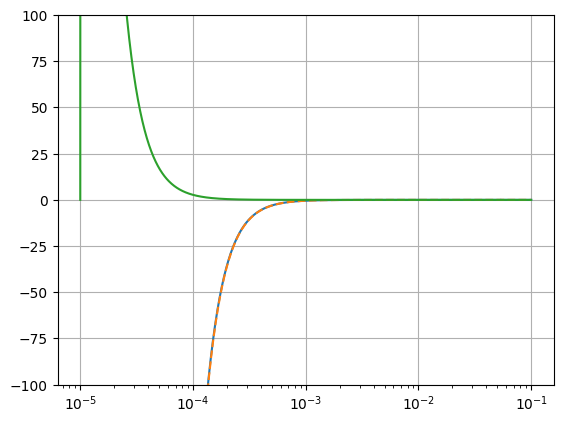

In [64]:
plt.semilogx(f1[0], tf1[(2,2)][0] / DAY - mbhb_parameters1["coalescence_time"])
plt.semilogx(f2[0], tf2[(2,2)][0] / DAY - mbhb_parameters1["coalescence_time"], linestyle="--")
plt.semilogx(f1[0], tf1[(2,2)][0] / DAY - tf2[(2,2)][0] / DAY)
plt.ylim(-100, 100)
plt.grid()